Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Dataset Loaded Successfully!

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1000 non-null   object
 1   text    1000 non-null   object
 2   label   1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB
None

First 5 Rows:
                                          title  \
0    Government Announces New Education Reforms   
1               Economy Shows Signs of Recovery   
2                   Aliens Land in Central Park   
3                   Aliens Land in Central Park   
4  New Study Reveals Health Benefits of Walking   

                                                text label  
0  The education ministry has proposed reforms to...  real  
1  The new study conducted by international resea...  real  
2  Sources claim that extraterrestrial beings wer...  fake  
3  The celebrity stated that secret documents rev...  fake

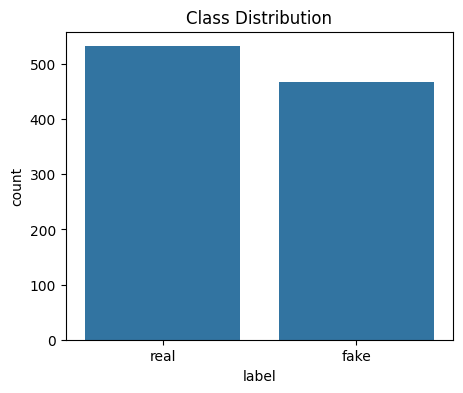

Text Cleaning Completed!

Model: Logistic Regression
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



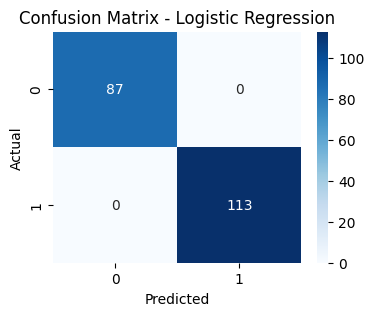

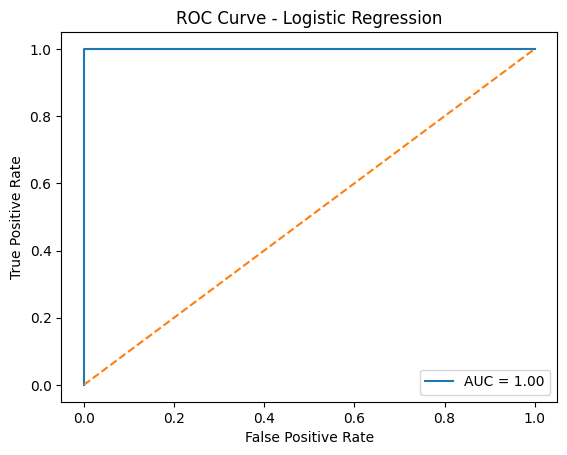


Model: Decision Tree
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



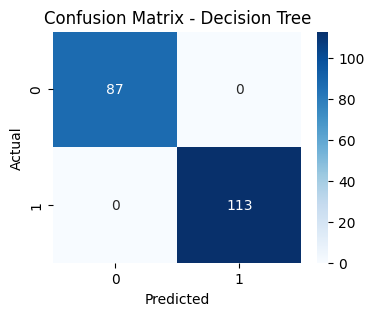

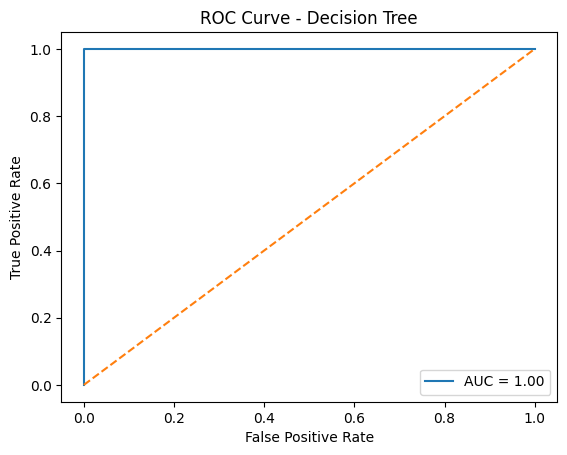


Model: Random Forest
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



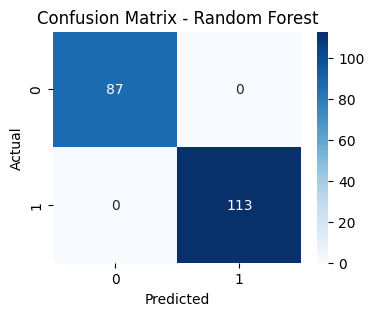

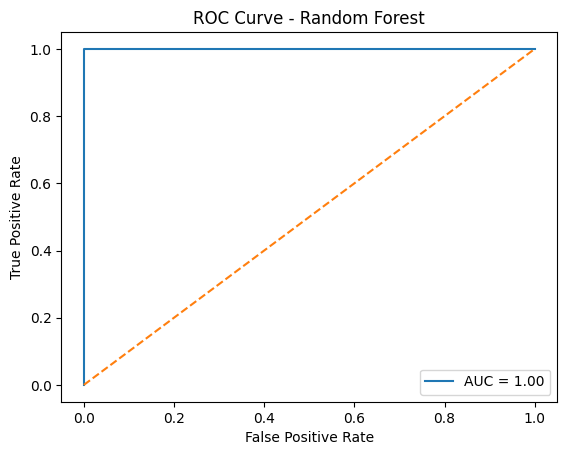


Model: Naive Bayes
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



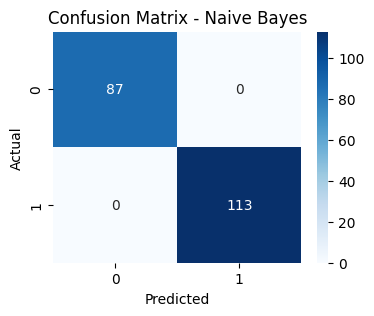

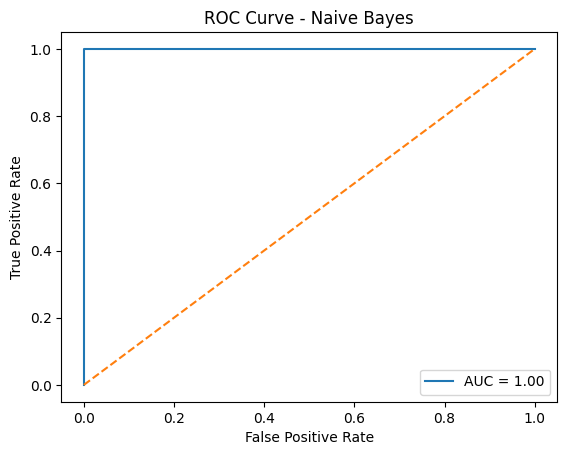


Model: KNN
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



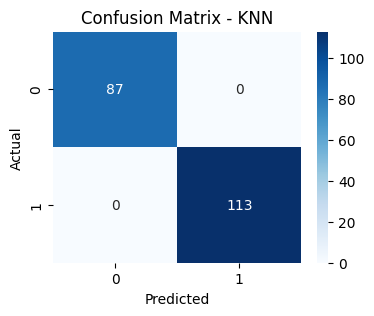

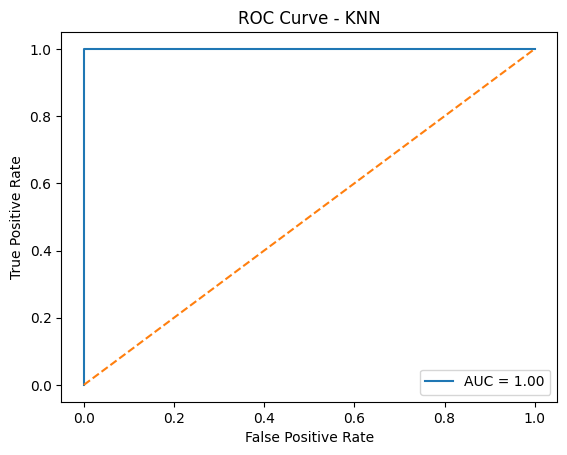


Model: ANN (MLP)
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00       113

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



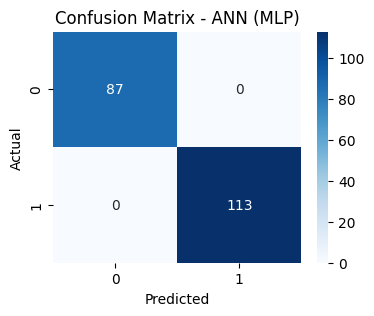

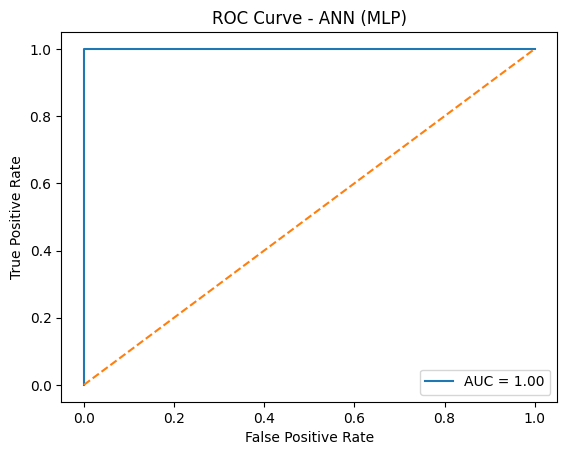


Final Model Comparison:

                 Model  Accuracy  Precision  Recall  F1 Score  AUC
0  Logistic Regression       1.0        1.0     1.0       1.0  1.0
1        Decision Tree       1.0        1.0     1.0       1.0  1.0
2        Random Forest       1.0        1.0     1.0       1.0  1.0
3          Naive Bayes       1.0        1.0     1.0       1.0  1.0
4                  KNN       1.0        1.0     1.0       1.0  1.0
5            ANN (MLP)       1.0        1.0     1.0       1.0  1.0


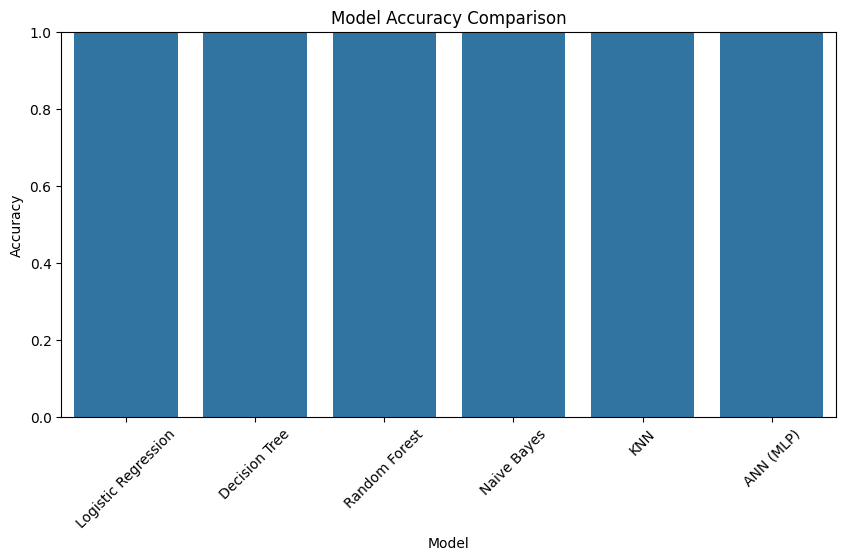

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

nltk.download('stopwords')

# STEP 2: Load Dataset

file_path = '/content/drive/MyDrive/ml.zip'   # Change path if needed
data = pd.read_csv(file_path, encoding='utf-8')

print("Dataset Loaded Successfully!\n")

#STEP 3: Data Understanding

print("Dataset Info:\n")
print(data.info())

print("\nFirst 5 Rows:")
print(data.head())

print("\nMissing Values:")
print(data.isnull().sum())

data.dropna(inplace=True)

# Target Distribution

plt.figure(figsize=(5,4))
sns.countplot(x='label', data=data)
plt.title("Class Distribution")
plt.show()


# STEP 4: Text Preprocessing


stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

data['cleaned_text'] = data['text'].apply(clean_text)

print("Text Cleaning Completed!")


# STEP 5: Feature Extraction


tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['cleaned_text'])

le = LabelEncoder()
y = le.fit_transform(data['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 6: Model Training


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "ANN (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)
}

results = []


# STEP 7: Training & Evaluation


for name, model in models.items():

    print(f"\n==============================")
    print(f"Model: {name}")
    print("==============================")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1 Score :", f1)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0,1], [0,1], linestyle='--')
        plt.title(f"ROC Curve - {name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()
    else:
        roc_auc = "N/A"

    results.append([name, acc, prec, rec, f1, roc_auc])

# STEP 8: Final Comparison Table


results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC"
])

print("\nFinal Model Comparison:\n")
print(results_df)

plt.figure(figsize=(10,5))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()
